This piece of code performs training of the NN against the PDF data. Prepared PDF data is required to run this code. The labels for data are taken from the names of each dataset, so better be prepared for labelling. In principle, this code can process both calculated PDF data, as well as experimental PDF data. The latter may require additinal processing which is performed by 'preparePDFexp.ipynb'. Calculated data may be prepared from a batch of xyz files by 'preparePDF.ipynb'

In [11]:
import numpy as np
np.random.seed(1337) 
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler, Normalizer
from keras.models import Sequential
from keras.layers import Dense, Conv1D, BatchNormalization, MaxPooling1D, LeakyReLU, Flatten, Dropout
from keras_self_attention import SeqSelfAttention
from keras.utils import custom_object_scope
from keras.callbacks import History, ModelCheckpoint, EarlyStopping
from keras import backend as K
from keras import metrics, regularizers
from keras.optimizers import Adam, Adagrad, Adadelta, RMSprop
from keras_tuner import RandomSearch, Hyperband
from keras_tuner.engine.hyperparameters import HyperParameters
from sklearn.metrics import confusion_matrix, recall_score, f1_score, precision_score
import keras.regularizers
import keras
import glob
import os
import itertools
import fnmatch

In [2]:
os.chdir('/Users/dimitrygrebenyuk/Yandex.Disk.localized/Working/PDF/Refinements/PDF-Cluster-Prediction/th_clusters/ce_groups')

In [3]:
files_calc = glob.glob('*.dat')

Counts of clusters by their nuclearity: {'1': 2535, '2': 2765, '3': 2069, '4': 1297, '5': 704, '6': 377, '7': 160, '8': 66, '9': 25}
Sliced cluster catalogue: ['4_2479.dat', '2_8469.dat', '5_1602.dat', '2_2622.dat', '3_9005.dat', '4_155.dat', '2_4253.dat', '4_1170.dat', '1_9917.dat', '1_3584.dat', '2_9011.dat', '1_2842.dat', '3_5159.dat', '2_6336.dat', '1_3590.dat', '2_7028.dat', '5_3767.dat', '2_2150.dat', '4_8140.dat', '3_7982.dat', '2_2636.dat', '2_4247.dat', '4_5302.dat', '1_4599.dat', '4_3773.dat', '2_6450.dat', '3_1465.dat', '4_9510.dat', '3_7014.dat', '4_169.dat', '4_4034.dat', '2_1317.dat', '2_6478.dat', '5_7529.dat', '5_9504.dat', '3_9987.dat', '3_8441.dat', '2_5617.dat', '3_9993.dat', '5_408.dat', '7_4098.dat', '3_8455.dat', '2_3272.dat', '3_7766.dat', '2_8327.dat', '5_6145.dat', '4_2451.dat', '3_4509.dat', '2_1303.dat', '3_1471.dat', '2_3514.dat', '5_2323.dat', '1_8374.dat', '1_7047.dat', '1_7721.dat', '2_3299.dat', '3_303.dat', '3_7799.dat', '1_9718.dat', '3_2839.dat', '2_6

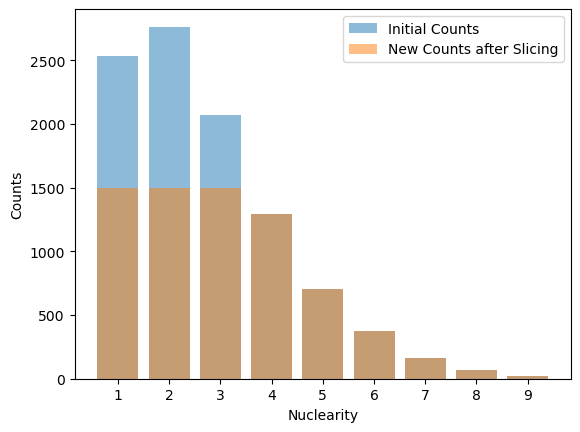

In [4]:
from collections import defaultdict
import matplotlib.pyplot as plt

def analyze_filenames(filenames):
    # Count how many filenames start with each digit from 1 to 9
    counts = defaultdict(int)
    for filename in filenames:
        if filename[0].isdigit() and filename[0] != '0':
            counts[filename[0]] += 1
            
    return counts

def create_output_array(filenames, selected_counts):
    # Create the output array based on the selected counts for each digit
    output_array = []
    current_counts = defaultdict(int)
    for filename in filenames:
        digit = filename[0]
        if digit in selected_counts and current_counts[digit] < selected_counts[digit]:
            output_array.append(filename)
            current_counts[digit] += 1
            
    return output_array

counts = analyze_filenames(files_calc)
sorted_counts = {str(digit): counts.get(str(digit), 0) for digit in range(1, 10)}
print("Counts of clusters by their nuclearity:", sorted_counts)

selected_counts = {
    '1': 1500, # Specify how many filenames starting with '1' you want
    '2': 1500, # Specify how many filenames starting with '2' you want
    '3': 1500,  # Specify how many filenames starting with '3' you want
    '4': 1500,  # Specify how many filenames starting with '3' you want
    '5': 1500,  # Specify how many filenames starting with '3' you want
    '6': 1500,  # Specify how many filenames starting with '3' you want
    '7': 1500,  # Specify how many filenames starting with '3' you want
    '8': 1500,  # Specify how many filenames starting with '3' you want
    '9': 1500  # Specify how many filenames starting with '3' you want
}

files_calc_sliced = create_output_array(files_calc, selected_counts)
print("Sliced cluster catalogue:", files_calc_sliced)

counts = analyze_filenames(files_calc_sliced)
sorted_counts2 = {str(digit): counts.get(str(digit), 0) for digit in range(1, 10)}
print("Counts of clusters by their nuclearity:", sorted_counts2)

digits = list(sorted_counts.keys())
initial_values = list(sorted_counts.values())
new_values = list(sorted_counts2.values()) # Use sorted counts for the new values

total_elements_in_sliced = len(files_calc_sliced)
print("Total number of elements in the sliced cluster catalogue:", total_elements_in_sliced)



plt.bar(digits, initial_values, alpha=0.5, label='Initial Counts')
plt.bar(digits, new_values, alpha=0.5, label='New Counts after Slicing')
plt.xlabel('Nuclearity')
plt.ylabel('Counts')
plt.legend()
plt.show()


In [5]:
raw_data_points = []

with open('labels.txt', 'w') as labels:
    for f in files_calc_sliced:
        df = pd.read_csv(f, usecols=[1], skiprows=201, header=None, delim_whitespace=True, skipfooter=800, engine='python')
        raw_data_points.append(df.values.ravel())
        labels.write(f[0])
        labels.write('\n')
    # for f in files_exp:
        # df = pd.read_csv(f, usecols=[1], skiprows=1, header=None, delim_whitespace=True, skipfooter=1, engine='python')
        # raw_data_points.append(df.values.ravel())
        # labels.write(f[0])
        # labels.write('\n')
        
raw_data_points = np.array(raw_data_points)

# Load the labels
labels = pd.read_csv("labels.txt", header=None)
labels = labels.values.ravel()  # convert the labels to a 1D array

2


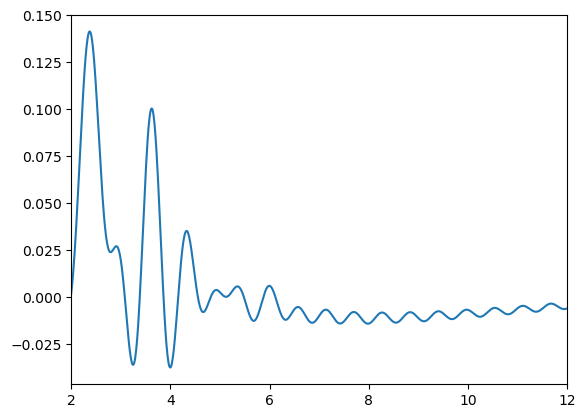

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
# Preprocessing
#scaler = MinMaxScaler()
#scaler = StandardScaler()
#scaler =MaxAbsScaler()
#data_points = scaler.fit_transform(data_points)
normalize = Normalizer()
data_points = normalize.fit_transform(raw_data_points)
fig, ax = plt.subplots()
ax.set_xlim(2,12)
ax.plot(np.arange(len(data_points[113,:]))/100+2, data_points[113,:])
print(labels[113])


In [6]:
# Split the data into training, validation and test sets
X_train, X_temp, y_train, y_temp = train_test_split(data_points, labels, test_size=0.2, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [7]:
# Tuning of the model

model = Sequential()
# Add the convolutional layers
model.add(Conv1D(filters=32, kernel_size=256, activation='relu', input_shape=(1200, 1))) # 256, 32
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2)) # 2
model.add(Dropout(0.5))
model.add(Conv1D(filters=64, kernel_size=32, activation='relu')) # 64, 32
model.add(Dropout(0.5))

model.add(SeqSelfAttention(attention_width=16, attention_type=SeqSelfAttention.ATTENTION_TYPE_MUL)) # 16

# Flatten the output of the convolutional layers
model.add(Flatten())

# Add the fully connected layers
model.add(Dense(units=128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01))) # 128 0.01
model.add(Dropout(0.5))
model.add(Dense(units=10, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.01))) # 10 0.01

# Compile the model
optimizer = RMSprop(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 945, 32)           8224      
                                                                 
 batch_normalization (BatchN  (None, 945, 32)          128       
 ormalization)                                                   
                                                                 
 max_pooling1d (MaxPooling1D  (None, 472, 32)          0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 472, 32)           0         
                                                                 
 conv1d_1 (Conv1D)           (None, 441, 64)           65600     
                                                                 
 dropout_1 (Dropout)         (None, 441, 64)           0

In [8]:
# Train the model
num_epochs = 40

checkpoint = ModelCheckpoint("ce_calc_0-12.hdf5", monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)

seqModel = model.fit(X_train, y_train, epochs=num_epochs, validation_data=(X_val, y_val), callbacks=[checkpoint], batch_size=128)
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_val, y_val)
print('Validation accuracy:', test_acc)

Epoch 1/40


2023-08-09 11:37:29.880475: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


63/63 [==============================] - ETA: 0s - loss: 2.4666 - accuracy: 0.5761
Epoch 1: val_accuracy improved from -inf to 0.29100, saving model to ce_calc_0-12.hdf5
63/63 [==============================] - 34s 528ms/step - loss: 2.4666 - accuracy: 0.5761 - val_loss: 2.2618 - val_accuracy: 0.2910
Epoch 2/40
63/63 [==============================] - ETA: 0s - loss: 0.9461 - accuracy: 0.7239
Epoch 2: val_accuracy improved from 0.29100 to 0.36000, saving model to ce_calc_0-12.hdf5
63/63 [==============================] - 33s 515ms/step - loss: 0.9461 - accuracy: 0.7239 - val_loss: 2.1156 - val_accuracy: 0.3600
Epoch 3/40
63/63 [==============================] - ETA: 0s - loss: 0.7811 - accuracy: 0.7727
Epoch 3: val_accuracy improved from 0.36000 to 0.42500, saving model to ce_calc_0-12.hdf5
63/63 [==============================] - 34s 532ms/step - loss: 0.7811 - accuracy: 0.7727 - val_loss: 2.0903 - val_accuracy: 0.4250
Epoch 4/40
63/63 [==============================] - ETA: 0s - loss

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


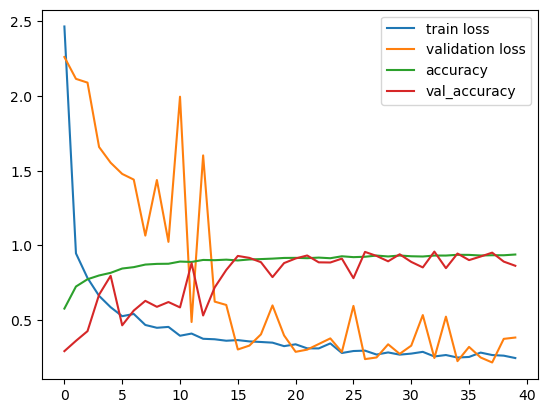

In [12]:
print(seqModel.history.keys())
xc         = range(num_epochs)

plt.plot(xc, seqModel.history['loss'], label='train loss')
plt.plot(xc, seqModel.history['val_loss'], label='validation loss')
plt.plot(xc, seqModel.history['accuracy'], label='accuracy')
plt.plot(xc, seqModel.history['val_accuracy'], label='val_accuracy')
plt.legend()

In [13]:
with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
    load_model = keras.models.load_model('ce_calc_0-12.hdf5')

In [16]:
load_model.evaluate(X_test, y_test)
y_pred_prob = load_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
confusion = confusion_matrix(y_test, y_pred)
recall = recall_score(y_test, y_pred, average=None)
f1 = f1_score(y_test, y_pred, average=None)
precision = precision_score(y_test, y_pred, average=None)
print('Confusion matrix', confusion)
print('Recall score:', recall)
print('F1 score:', f1)
print('Precision score:', precision)

32/32 [==============================] - 1s 32ms/step
Confusion matrix [[248   0   0   0   0   0   0   0   0]
 [  0 284   0   0   0   0   0   0   0]
 [  0   0 190   0   0   0   0   0   0]
 [  0   0   4 131   0   0   0   0   0]
 [  0   0   0   6  69   0   0   0   0]
 [  0   0   0   0  13  23   4   0   0]
 [  0   0   0   0   1   1  17   0   0]
 [  0   0   0   0   0   0   8   0   0]
 [  0   0   0   0   0   0   1   0   0]]
Recall score: [1.         1.         1.         0.97037037 0.92       0.575
 0.89473684 0.         0.        ]
F1 score: [1.         1.         0.98958333 0.96323529 0.87341772 0.71875
 0.69387755 0.         0.        ]
Precision score: [1.         1.         0.97938144 0.95620438 0.8313253  0.95833333
 0.56666667 0.         0.        ]


/Users/dimitrygrebenyuk/miniforge3/envs/keras/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Confusion matrix, without normalization
[[248   0   0   0   0   0   0   0   0]
 [  0 284   0   0   0   0   0   0   0]
 [  0   0 190   0   0   0   0   0   0]
 [  0   0   4 131   0   0   0   0   0]
 [  0   0   0   6  69   0   0   0   0]
 [  0   0   0   0  13  23   4   0   0]
 [  0   0   0   0   1   1  17   0   0]
 [  0   0   0   0   0   0   8   0   0]
 [  0   0   0   0   0   0   1   0   0]]


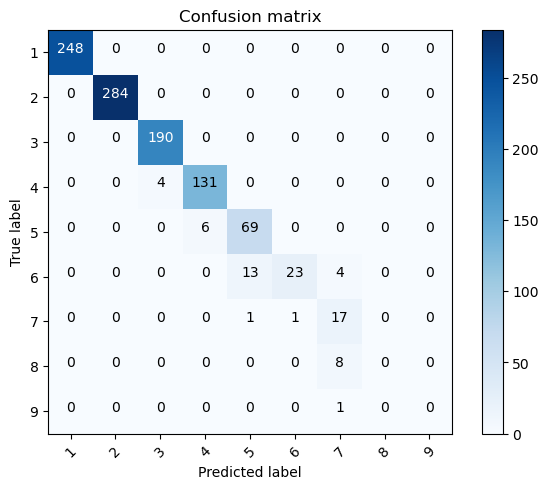

In [17]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)
    
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Plot the confusion matrix
plot_confusion_matrix(confusion, classes = np.unique(y_test), title='Confusion matrix', normalize=False)
plt.show()

Hyperparameter tuning

In [7]:
# Let's do some hyperparameter tuning

def build_model(hp):
    model = Sequential()
    model.add(Conv1D(filters=hp.Choice('filters1', [8, 16, 32]),
                     kernel_size=hp.Choice('kernel_size1', [64, 128, 256]),
                     activation='relu', input_shape=(1000, 1)))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(hp.Float('dropout', 0.2, 0.6, step=0.1)))
    model.add(Conv1D(filters=hp.Choice('filters2', [32, 64, 128]),
                     kernel_size=hp.Choice('kernel_size2', [16, 32, 64]),
                     activation='relu'))
    model.add(Dropout(hp.Float('dropout', 0.2, 0.6, step=0.1)))
    model.add(SeqSelfAttention(attention_width=16, attention_type=SeqSelfAttention.ATTENTION_TYPE_MUL))
    model.add(Flatten())
    model.add(Dense(units=hp.Choice('dense_units', [64, 128, 256]), activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)))
    model.add(Dropout(hp.Float('dropout', 0.2, 0.6, step=0.1)))
    model.add(Dense(units=10, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.01)))
    optimizer = Adam(learning_rate=hp.Float('learning_rate', 1e-4, 1e-1, sampling='log'))
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


In [8]:
# Split the data into training, validation and test sets
X_train, X_temp, y_train, y_temp = train_test_split(data_points, labels, test_size=0.2, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [12]:
tuner = Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=30,
    factor=3,
    project_name='hyperband_2-12'
)

tuner.search(X_train, y_train, epochs=50, validation_data=(X_val, y_val), callbacks=[EarlyStopping(monitor='val_loss', patience=3)])

Trial 90 Complete [00h 02m 40s]
val_accuracy: 0.43478259444236755

Best val_accuracy So Far: 0.9803646802902222
Total elapsed time: 02h 14m 36s
INFO:tensorflow:Oracle triggered exit


In [13]:
tuner.search_space_summary()
best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
print(best_hyperparameters.values)
best_model = tuner.get_best_models(num_models=1)[0]
best_model.save('tuned_sliced_ce_calc_2-12.h5')

Search space summary
Default search space size: 7
filters1 (Choice)
{'default': 8, 'conditions': [], 'values': [8, 16, 32], 'ordered': True}
kernel_size1 (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128, 256], 'ordered': True}
dropout (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.6, 'step': 0.1, 'sampling': 'linear'}
filters2 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
kernel_size2 (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 64], 'ordered': True}
dense_units (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128, 256], 'ordered': True}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.1, 'step': None, 'sampling': 'log'}
{'filters1': 8, 'kernel_size1': 256, 'dropout': 0.4, 'filters2': 32, 'kernel_size2': 16, 'dense_units': 256, 'learning_rate': 0.00017761282938388254, 'tuner/epochs': 30, 'tuner/initial_epoch': 10, 'tuner/bracket': 3, 

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_2 (Conv1D)           (None, 745, 8)            2056      
                                                                 
 batch_normalization_1 (Batc  (None, 745, 8)           32        
 hNormalization)                                                 
                                                                 
 max_pooling1d_1 (MaxPooling  (None, 372, 8)           0         
 1D)                                                             
                                                                 
 dropout_3 (Dropout)         (None, 372, 8)            0         
                                                                 
 conv1d_3 (Conv1D)           (None, 357, 32)           4128      
                                                                 
 dropout_4 (Dropout)         (None, 357, 32)          

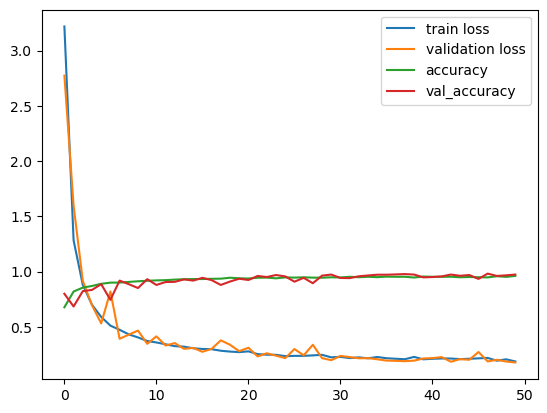

In [14]:
# Retrain the model if needed
num_epochs = 50

model = Sequential()
model.add(Conv1D(filters=8, kernel_size=256, activation='relu', input_shape=(1000, 1)))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2)) # 2
model.add(Dropout(0.4))
model.add(Conv1D(filters=32, kernel_size=16, activation='relu'))
model.add(Dropout(0.4))
model.add(SeqSelfAttention(attention_width=16, attention_type=SeqSelfAttention.ATTENTION_TYPE_MUL))
model.add(Flatten())
model.add(Dense(units=256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01))) # 128 0.01
model.add(Dropout(0.4))
model.add(Dense(units=10, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.01))) # 10 0.01

# Compile the model
optimizer = Adam(learning_rate=0.0001776)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

checkpoint = ModelCheckpoint("tuned_sliced_сe_calc_2-12_retrain.h5", monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)

seqModel = model.fit(X_train, y_train, epochs=num_epochs, validation_data=(X_val, y_val), callbacks=[checkpoint])
# Evaluate the model on the validation set
test_loss, test_acc = model.evaluate(X_val, y_val)
print('Validation accuracy:', test_acc)

print(seqModel.history.keys())
xc         = range(num_epochs)

plt.plot(xc, seqModel.history['loss'], label='train loss')
plt.plot(xc, seqModel.history['val_loss'], label='validation loss')
plt.plot(xc, seqModel.history['accuracy'], label='accuracy')
plt.plot(xc, seqModel.history['val_accuracy'], label='val_accuracy')
plt.legend()